## Installation des packages nécessaires

- s3prl : framework d'extraction de features audio
- soundfile : lecture/écriture de fichiers audio
- torchaudio : traitement audio avec PyTorch
- librosa : traitement audio
- tqdm : barre de progression

In [71]:
# %pip install --upgrade pip setuptools wheel
#
# %pip install s3prl --upgrade
# %pip install huggingface_hub -- upgrade
#
# %pip install soundfile --upgrade
# %pip install torchaudio --upgrade
# %pip install librosa --upgrade
#
# %pip install tqdm --upgrade
# %pip install scikit-learn --upgrade
# %pip install matplotlib --upgrade

## Import des packages

- tqdm : barre de progression
- pathlib : gestion des chemins de fichiers
- librosa : traitement audio
- os : gestion des fichiers
- torch : PyTorch
- numpy : calculs numériques
- soundfile : lecture/écriture de fichiers audio
- s3prl : framework d'extraction de features audio
- sklearn : outils de machine learning

In [72]:
import os
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import soundfile as sf
import torch
from s3prl.nn import S3PRLUpstream
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm

## Paramètres globaux

- random_seed : graine aléatoire pour reproductibilité
- device : choix du device (GPU si disponible, sinon CPU)
- dataset_path : chemin vers le dataset audio original
- audio_path : chemin vers le dossier de sauvegarde des audios rééchantillonnés
- embedding_path : chemin vers le dossier de sauvegarde des embeddings extraits

In [73]:
random_seed = 42
limit = 200

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

shared_dataset_path = Path("../Dataset/")
data_path = Path("./dataset/")

# Train Dev Test
train_path = data_path / "train"
dev_path = data_path / "dev"
test_path = data_path / "test"

# Embedding paths
train_embedding_path = train_path / "embedding"
dev_embedding_path = dev_path / "embedding"
test_embedding_path = test_path / "embedding"

# Pooled versions paths
train_pooled_path = train_path / "pooled"
dev_pooled_path = dev_path / "pooled"
test_pooled_path = test_path / "pooled"

train_path.mkdir(exist_ok=True)
dev_path.mkdir(exist_ok=True)
test_path.mkdir(exist_ok=True)
train_embedding_path.mkdir(exist_ok=True)
dev_embedding_path.mkdir(exist_ok=True)
test_embedding_path.mkdir(exist_ok=True)
train_pooled_path.mkdir(exist_ok=True)
dev_pooled_path.mkdir(exist_ok=True)
test_pooled_path.mkdir(exist_ok=True)

AUDIO_EXTENSIONS = (".wav")
EMBEDDING_EXTENSIONS = (".pt")
DATASET_USED = ["Ravdess", "Tess"]
SAMPLING_RATE = 16000
BATCH_SIZE = 8  # ajuster selon ton GPU
POOLING_TYPES = ["mean", "max", "mean_std"]

Device: cpu


## Rééchantillonnage des fichiers audio à 16kHz et sauvegarde
- On parcourt le dataset original
- Si l'échantillonnage n'est pas à 16kHz
  - On rééchantillonne chaque fichier à 16kHz si nécessaire
  - On remplace les fichiers par ceux rééchantillonnés

In [74]:
# Séparatin des fichiers en train/dev/test
list_files = []
nb_treated_files = 0
total_files = 0

for subdir, dirs, files in os.walk(shared_dataset_path):
    for dataset_name in DATASET_USED:
        if dataset_name in subdir:
            for file in files:
                if file.lower().endswith(AUDIO_EXTENSIONS):
                    y, sr = librosa.load(Path(subdir) / file, sr=None)  # sr=None garde la fréquence originale

                    if sr != SAMPLING_RATE:
                        nb_treated_files += 1
                        # Re-échantillonner
                        y_resampled = librosa.resample(y, orig_sr=sr, target_sr=SAMPLING_RATE)

                        # Sauvegarder
                        sf.write(Path(subdir) / file, y_resampled, SAMPLING_RATE)

                    list_files.append(Path(subdir) / file)
                    total_files += 1
train_files, temp_files = train_test_split(list_files, test_size=0.3, random_state=random_seed)
dev_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=random_seed)

print(f"Number of files re-sampled and saved: {nb_treated_files}")
print(f"Total number of files : {total_files}")

print(f"Number of files in train set: {len(train_files)}")
print(f"Number of files in dev set: {len(dev_files)}")
print(f"Number of files in test set: {len(test_files)}")

Number of files re-sampled and saved: 0
Total number of files : 4240
Number of files in train set: 2968
Number of files in dev set: 636
Number of files in test set: 636


## Fonctions utilitaires pour associer les fichiers audio à leurs émotions
- find_emotion_T : fonction pour la base TESS
- emotionfix : fonction pour ajuster les indices d'émotions pour la classification

In [75]:
# Emotion kind validation function for TESS database, due to emotions written within the file names.
def find_emotion_T(name):
    if 'neutral' in name:
        return "01"
    elif 'happy' in name or 'joy' in name or 'positive' in name:
        return "03"
    elif 'sad' in name or 'sadness' in name or 'pain' in name:
        return "04"
    elif 'angry' in name or 'anger' in name:
        return "05"
    elif 'fear' in name:
        return "06"
    elif 'disgust' in name or 'negative' in name:
        return "07"
    elif 'ps' in name or 'surprise' in name:
        return "08"
    else:
        return "-1"


# 'emotions' list fix for classification purposes:
#     Classification values start from 0, Thus an 'n = n-1' operation has been executed for both RAVDESS and TESS databases:
def emotionfix(e_num):
    if e_num == "01":
        return 0  # neutral
    elif e_num == "02":
        return 1  # calm
    elif e_num == "03":
        return 2  # happy
    elif e_num == "04":
        return 3  # sad
    elif e_num == "05":
        return 4  # angry
    elif e_num == "06":
        return 5  # fear
    elif e_num == "07":
        return 6  # disgust
    else:
        return 7  # suprised


## Load du modèle upstream WavLM via S3PRL et extraction des embeddings
- On liste les modèles disponibles via torch.hub
- On choisit le modèle WavLM (large de préférence)
- On charge le modèle upstream (téléchargement si nécessaire)

In [76]:
# 1) lister les modèles exposés via torch.hub (optionnel mais utile)
print("Listing available torch.hub upstreal models from s3prl (may take 1-2s)...")
try:
    hub_list = torch.hub.list('s3prl/s3prl')
    print("Some available models (first 30):\n", hub_list[:30])
except Exception as e:
    print("Impossible de lister via torch.hub:", e)
    hub_list = []

# 2) choisir un upstream (essaye wavlm_large, sinon wavlm_base_plus, sinon 'wavlm' puis tu pourras adapter)
chosen = "wavlm_large"
print(f"\nWill try to load upstream name: {chosen}")

# 3) load the upstream model (this will download checkpoint if needed)
upstream_model = S3PRLUpstream(chosen)
upstream_model.to(device)
upstream_model.eval()
print("Loaded upstream:", chosen)

Listing available torch.hub upstreal models from s3prl (may take 1-2s)...


Using cache found in /Users/alves/.cache/torch/hub/s3prl_s3prl_main


Some available models (first 30):
 ['FileLock', 'Path', 'apc', 'apc_360hr', 'apc_960hr', 'apc_local', 'apc_url', 'ast', 'audio_albert', 'audio_albert_960hr', 'audio_albert_local', 'audio_albert_logMelBase_T_share_AdamW_b32_1m_960hr_drop1', 'audio_albert_url', 'baseline', 'baseline_local', 'byol_a_1024', 'byol_a_2048', 'byol_a_512', 'byol_s_cvt', 'byol_s_default', 'byol_s_resnetish34', 'contentvec', 'contentvec_km100', 'contentvec_km500', 'cpc_local', 'cpc_url', 'customized_upstream', 'cvhubert', 'data2vec', 'data2vec_base_960']

Will try to load upstream name: wavlm_large
Loaded upstream: wavlm_large


## Extraction des embeddings et sauvegarde
- On parcourt les fichiers audio rééchantillonnés
- On charge chaque fichier audio
- On extrait les embeddings via le modèle upstream
- On sauvegarde les embeddings extraits

In [77]:
import numpy as np


def process_batch(wavs, save_paths, device, upstream_model, pooling_types=["mean", "max", "mean_std"]):
    """
    wavs: list of numpy arrays (audio samples)
    save_paths: list of Path objects (base path for saving embeddings)
    """
    lengths = [len(w) for w in wavs]
    max_len = max(lengths)

    # --- Padding ---
    padded = np.zeros((len(wavs), max_len), dtype=np.float32)
    for i, w in enumerate(wavs):
        padded[i, :len(w)] = w

    wav_tensor = torch.from_numpy(padded).to(device)
    wav_len = torch.LongTensor(lengths).to(device)

    # --- Extraction embeddings ---
    with torch.no_grad():
        all_hs, _ = upstream_model(wav_tensor, wav_len)

    emb_batch = all_hs[-1].cpu()  # shape (B, T, D)

    # --- Sauvegarde embeddings et pooling ---
    for i, base_path in enumerate(save_paths):  # we enumerate all the
        emb = emb_batch[i, :lengths[i]]  # retire le padding

        # 1) Frame-level embeddings pour Transformer
        emb_dir = base_path.parent / "embedding"
        emb_path = emb_dir / f"{base_path.name}.pt"

        if not emb_path.exists():
            torch.save(emb, emb_path)

        # 2) Pooled embeddings pour MLP
        for pooling_type in pooling_types:
            pooled_dir = base_path.parent / "pooled" / pooling_type
            pooled_dir.mkdir(parents=True, exist_ok=True)
            pooled_path = pooled_dir / f"{base_path.name}.pt"

            if pooled_path.exists():
                continue

            if pooling_type == "mean":
                emb_pooled = emb.mean(dim=0)
            elif pooling_type == "max":
                emb_pooled, _ = emb.max(dim=0)
            elif pooling_type == "mean_std":
                emb_mean = emb.mean(dim=0)
                emb_std = emb.std(dim=0)
                emb_pooled = torch.cat([emb_mean, emb_std])
            else:
                raise ValueError(f"Unknown pooling type: {pooling_type}")

            torch.save(emb_pooled, pooled_path)


## On pool les embeddings extraits pour classification
- On definit les types de pooling à appliquer
- On crée un petit modèle transformer pour l'agrégation séquentielle
- On parcourt les fichiers d'embeddings extraits
- On applique tous les types de pooling pour chaque embedding
- On sauvegarde les embeddings formatés
- Types de pooling :
    - mean : moyenne (1024)
    - max : maximum (1024)
    - mean_std : concaténation de la moyenne et de l'écart-type (2048)
    - transformer : agrégation via un petit modèle transformer (1024)

In [78]:
nb_treated_file = 0
buffer_wavs = []
buffer_paths = []

for set, name in [(train_files, "train"), (dev_files, "dev"), (test_files, "test")]:

    for wav_path in tqdm(set, desc=f"Processing {name}"):

        # Skip si tous les pooled existent et le frame-level existe
        if set == train_files:
            base_path = train_path / wav_path.stem
            pooled_exist = all(
                (train_pooled_path / p / f"{wav_path.stem}.pt").exists()
                for p in POOLING_TYPES
            )
            embedding_exists = (train_embedding_path / f"{wav_path.stem}.pt").exists()
        elif set == dev_files:
            base_path = dev_path / wav_path.stem
            pooled_exist = all(
                (dev_pooled_path / p / f"{wav_path.stem}.pt").exists()
                for p in POOLING_TYPES
            )
            embedding_exists = (dev_embedding_path / f"{wav_path.stem}.pt").exists()
        elif set == test_files:
            base_path = test_path / wav_path.stem
            pooled_exist = all(
                (test_pooled_path / p / f"{wav_path.stem}.pt").exists()
                for p in POOLING_TYPES
            )
            embedding_exists = (test_embedding_path / f"{wav_path.stem}.pt").exists()

        if pooled_exist and embedding_exists:
            continue

        wav, sr = sf.read(str(wav_path))
        if sr != 16000:
            raise ValueError(f"{wav_path} is not 16kHz ({sr} Hz)")

        buffer_wavs.append(wav)
        buffer_paths.append(base_path)
        nb_treated_file += 1

        # --- Process batch si on atteint la taille ---
        if len(buffer_wavs) == BATCH_SIZE:
            process_batch(buffer_wavs, buffer_paths, device, upstream_model, POOLING_TYPES)
            buffer_wavs, buffer_paths = [], []

# --- Traiter le dernier batch restant ---
if buffer_wavs:
    process_batch(buffer_wavs, buffer_paths, device, upstream_model, POOLING_TYPES)

print(f"Number of files processed: {nb_treated_file}")

Processing test: 100%|██████████| 636/636 [00:00<00:00, 34843.87it/s]

Number of files processed: 0


## Split des embeddings en sets d'entrainement, validation et test
- On liste les chemins des fichiers d'embeddings
- On split les fichiers en set d'entrainement, validation et test
- On sauvegarde les splits

In [79]:
for dir in [train_pooled_path, dev_pooled_path, test_pooled_path]:
    for pooling in POOLING_TYPES:
        files = os.listdir(dir / pooling)

        torch.save(files, dir / ("_" + pooling + ".pt"))

# Même chose pour les embeddings non poolés (transformer)

# On supprime _transformer.pt de chaque dossier avant de recréer le fichier.
for path in [train_embedding_path, dev_embedding_path, test_embedding_path]:
    transformer_file = path / "_transformer.pt"
    if transformer_file.exists():
        print(f"Removing existing file: {transformer_file}")
        transformer_file.unlink()

train_files = os.listdir(train_embedding_path)
dev_files = os.listdir(dev_embedding_path)
test_files = os.listdir(test_embedding_path)

torch.save(train_files, train_embedding_path / "_transformer.pt")
torch.save(dev_files, dev_embedding_path / "_transformer.pt")
torch.save(test_files, test_embedding_path / "_transformer.pt")

print("Train split is composed of ", len(train_files), " files.")
print("Dev split is composed of ", len(dev_files), " files.")
print("Test split is composed of ", len(test_files), " files.\n")

Removing existing file: dataset/train/embedding/_transformer.pt
Removing existing file: dataset/dev/embedding/_transformer.pt
Removing existing file: dataset/test/embedding/_transformer.pt
Train split is composed of  2968  files.
Dev split is composed of  636  files.
Test split is composed of  636  files.



## Vérification des fichiers sauvegardés
On load un fichier du train set de la moyenne pour vérifier si on a bien sauvegardé correctement
- On load le training set de la moyenne
- On load un embedding de ce train set
- On affiche la forme de l'embedding

### Expected output
```
Number of training files (mean pooling): 72
Loading embedding file: xxxxxxx.pt
Embedding shape: torch.Size([1024])
```

In [80]:
# On load un fichier du train set pour vérifier

# On load le training sed de la moyenne
train_files = torch.load(train_pooled_path / "_mean.pt")
transformer_train_files = torch.load(train_embedding_path / "_transformer.pt")

print("Number of training files (mean pooling):", len(train_files))
print("Number of training files (transformer):", len(transformer_train_files))

dev_files = torch.load(dev_pooled_path / "_mean_std.pt")
transformer_dev_files = torch.load(dev_embedding_path / "_transformer.pt")

print("Number of dev files (mean_std pooling):", len(dev_files))
print("Number of dev files (transformer):", len(transformer_dev_files))

test_files = torch.load(test_pooled_path / "_max.pt")
transformer_test_files = torch.load(test_embedding_path / "_transformer.pt")

print("Number of testing files (max pooling):", len(test_files))
print("Number of testing files (transformer):", len(transformer_test_files))

# On load un embedding de ce train set
embedding_file = train_files[0]
transformer_embedding_file = transformer_train_files[0]
print("Loading embedding file:", embedding_file)
print("Loading transformer embedding file:", transformer_embedding_file)

embedding = torch.load(train_pooled_path / "mean" / embedding_file)
transformer_embedding = torch.load(train_embedding_path / transformer_embedding_file)
print("Embedding shape:", embedding.shape)
print("Transformer Embedding shape:", transformer_embedding.shape)

Number of training files (mean pooling): 2968
Number of training files (transformer): 2968
Number of dev files (mean_std pooling): 636
Number of dev files (transformer): 636
Number of testing files (max pooling): 636
Number of testing files (transformer): 636
Loading embedding file: OAF_make_disgust.pt
Loading transformer embedding file: OAF_make_disgust.pt
Embedding shape: torch.Size([1024])
Transformer Embedding shape: torch.Size([159, 1024])


## Chargement des differents sets pour la methode de pooling renseignée et association des enregistrements à leur label

In [81]:
def load_split(file_list, base_path, is_transformer=False):
    embeddings, labels = [], []
    nb_par_classes = [0 for _ in range(8)]

    for file_name in file_list:

        if not file_name.startswith("_") and file_name.endswith(".pt"):

            # 1) Charge l'embedding
            emb = torch.load(base_path / file_name)  # tensor

            # 2) Détecte l'émotion
            emo_code = find_emotion_T(file_name)
            if emo_code == "-1":
                emo_code = file_name[6:8]  # RAVDESS
            label = emotionfix(emo_code)
            nb_par_classes[label] += 1

            embeddings.append(emb)
            labels.append(label)
    if is_transformer:
        X = pad_sequence(embeddings, batch_first=True)
    else:
        X = torch.stack(embeddings)
    y = torch.tensor(labels)
    print("\t - ", nb_par_classes)

    return X, y, nb_par_classes


paths = {}
for pooling in POOLING_TYPES:
    dirs = []
    for dir in [train_pooled_path, dev_pooled_path, test_pooled_path]:
        dirs.append(dir / ("_" + pooling + ".pt"))
    paths[pooling] = dirs

pooling_type = "mean"  # "max", "mean_std", "transformer"

train_path, dev_path, test_path = paths[pooling_type]

train_files = torch.load(train_path)
dev_files = torch.load(dev_path)
test_files = torch.load(test_path)

print("Number of example for each class\nTrain :")
X_train, y_train, nb_train = load_split(train_files, train_pooled_path / pooling_type)
print("Dev  :")
X_dev, y_dev, nb_dev = load_split(dev_files, dev_pooled_path / pooling_type)
print("Test  :")
X_test, y_test, nb_test = load_split(test_files, test_pooled_path / pooling_type)

Number of example for each class
Train :
	 -  [349, 133, 425, 422, 396, 408, 422, 413]
Dev  :
	 -  [74, 30, 83, 84, 109, 101, 69, 86]
Test  :
	 -  [73, 29, 84, 94, 85, 81, 99, 91]


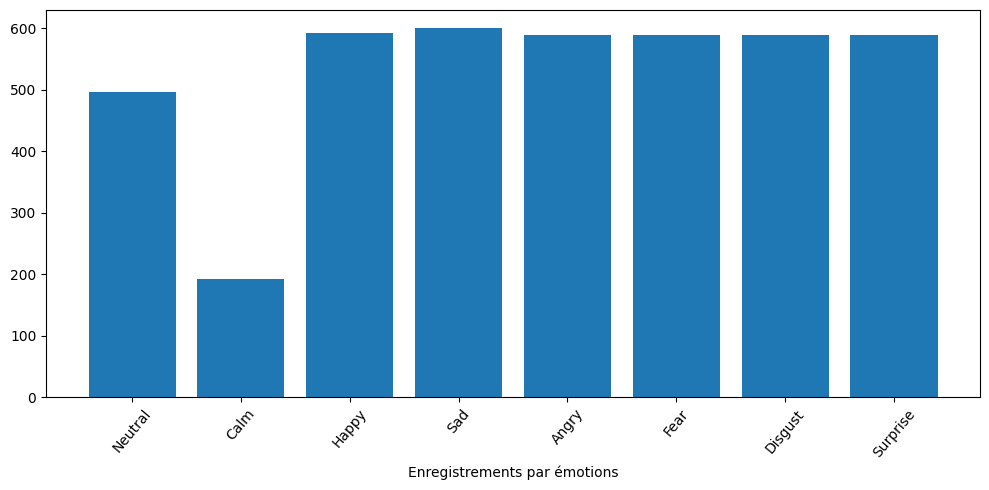

In [82]:
label_name = ['Neutral', 'Calm', 'Happy', 'Sad', 'Angry', 'Fear', 'Disgust', 'Surprise']

nb_record_by_emotion = []
for i in range(len(nb_train)):
    nb_record_by_emotion.append(nb_train[i] + nb_dev[i] + nb_test[i])

plt.figure(figsize=(10, 5))
plt.bar(label_name, nb_record_by_emotion)
plt.xticks(rotation=50)
plt.xlabel("Enregistrements par émotions")
plt.tight_layout()
plt.show()

In [83]:
print(f"[{pooling_type.upper()}] Loaded splits:")
print("Train :", X_train.shape, y_train.shape, y_train.unique())
print("Val   :", X_dev.shape, y_dev.shape, y_dev.unique())
print("Test  :", X_test.shape, y_test.shape, y_test.unique())

[MEAN] Loaded splits:
Train : torch.Size([2968, 1024]) torch.Size([2968]) tensor([0, 1, 2, 3, 4, 5, 6, 7])
Val   : torch.Size([636, 1024]) torch.Size([636]) tensor([0, 1, 2, 3, 4, 5, 6, 7])
Test  : torch.Size([636, 1024]) torch.Size([636]) tensor([0, 1, 2, 3, 4, 5, 6, 7])
